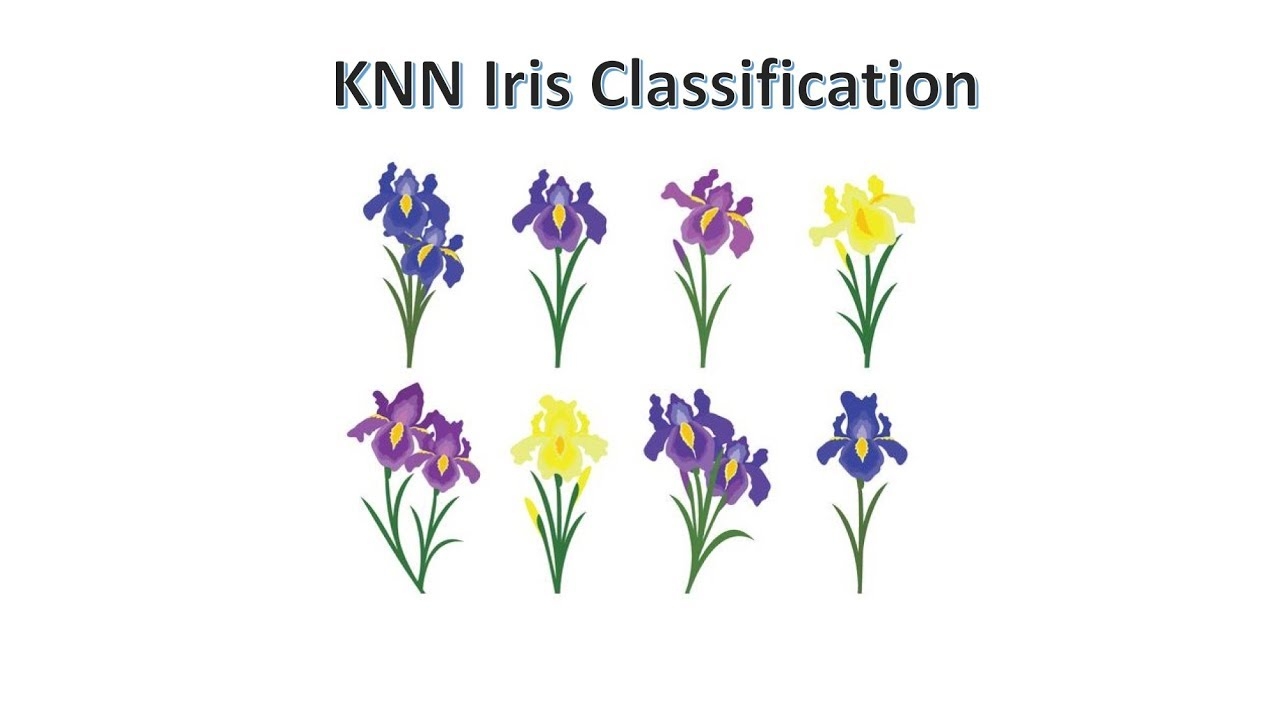

<div class="list-group" id="list-tab" role="tablist">
<h2 class="list-group-item list-group-item-action active" data-toggle="list" style='font-size:40px;background:black; border:0; color:white' role="tab" aria-controls="home"><center>TABLE OF CONTENTS</center></h2>

    
* [WHAT IS KNN?](#1)
* [THEORY](#2)
* [PROS AND CONS](#3)
* [HOW TO IMPROVE KNN?](#4)
* [OPTIMUM NUMBER OF NEIGHBORS IN K](#5)
* [IMPORTING LIBRARIES](#6)
* [READING AND UNDERSTANDING DATA](#7)
* [DATA INSPECTION](#8)
* [ENCODING CATEGORICAL COLUMNS](#9)
* [FEATURE SCALING](#10)
* [MODEL BUILDING](#11)
* [MODEL EVALUATION](#12)
* [MODEL PERFORMANCE USING CROSS-VALIDATION](#13)

<a id="1"></a>
<h2 style='background:black; border:10; color:white'><center>1) WHAT IS KNN?</center><h2>

The **K-nearest neighbors (KNN)** algorithm is a type of supervised machine learning algorithms. KNN is extremely easy to implement in its most basic form, and yet performs quite complex classification tasks. It is a lazy learning algorithm since it doesn't have a specialized training phase. Rather, it uses all of the data for training while classifying a new data point or instance. KNN is a non-parametric learning algorithm, which means that it doesn't assume anything about the underlying data. This is an extremely useful feature since most of the real world data doesn't really follow any theoretical assumption e.g. linear-separability, uniform distribution, etc.

<a id="2"></a>
<h2 style='background:black; border:10; color:white'><center>2) THEORY </center><h2>

The intuition behind the KNN algorithm is one of the simplest of all the supervised machine learning algorithms. It simply calculates the distance of a new data point to all other training data points. The distance can be of any type e.g Euclidean or Manhattan etc. It then selects the K-nearest data points, where K can be any integer. Finally it assigns the data point to the class to which the majority of the K data points belong.

Let's see this algorithm in action with the help of a simple example. Suppose you have a dataset with two variables, which when plotted, looks like the one in the following figure.



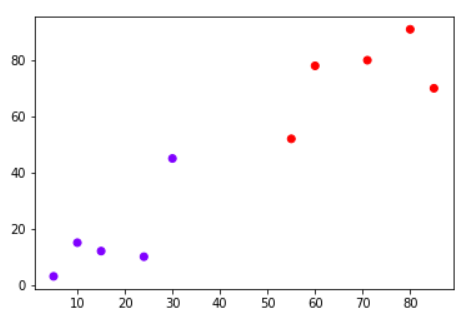

Your task is to classify a new data point with 'X' into "Blue" class or "Red" class. The coordinate values of the data point are x=45 and y=50. Suppose the value of K is 3. The KNN algorithm starts by calculating the distance of point X from all the points. It then finds the 3 nearest points with least distance to point X. This is shown in the figure below. The three nearest points have been encircled.



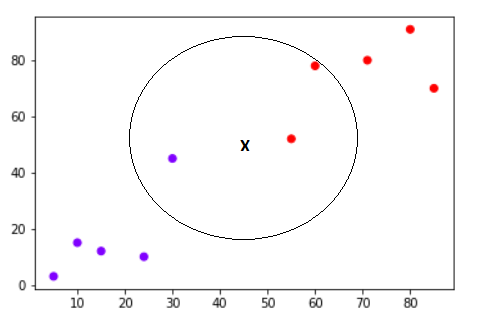

The final step of the KNN algorithm is to assign new point to the class to which majority of the three nearest points belong. From the figure above we can see that the two of the three nearest points belong to the class "Red" while one belongs to the class "Blue". Therefore the new data point will be classified as "Red".

<a id="3"></a>
<h2 style='background:black; border:10; color:white'><center>3) PROS AND CONS</center><h2>

## PROS:

* It is extremely easy to implement.

* As said earlier, it is lazy learning algorithm and therefore requires no training prior to making real time predictions. This makes the KNN algorithm much faster than other algorithms that require training e.g SVM, linear regression, etc.

* Since the algorithm requires no training before making predictions, new data can be added seamlessly.

* There are only two parameters required to implement KNN i.e. the value of K and the distance function (e.g. Euclidean or Manhattan etc.)

## CONS:

* The KNN algorithm doesn't work well with high dimensional data because with large number of dimensions, it becomes difficult for the algorithm to calculate distance in each dimension.

* The KNN algorithm has a high prediction cost for large datasets. This is because in large datasets the cost of calculating distance between new point and each existing point becomes higher.

* Finally, the KNN algorithm doesn't work well with categorical features since it is difficult to find the distance between dimensions with categorical features.

<a id="4"></a>
<h2 style='background:black; border:10; color:white'><center>4) HOW TO IMPROVE KNN? </center><h2>

For better results, normalizing data on the same scale is highly recommended. Generally, the normalization range considered between 0 and 1. KNN is not suitable for the large dimensional data. In such cases, dimension needs to reduce to improve the performance. Also, handling missing values will help us in improving results.

<a id="5"></a>
<h2 style='background:black; border:10; color:white'><center>5) OPTIMUM NUMBER OF NEIGHBORS IN K</center><h2>

At this point, the question arises that How to choose the optimal number of neighbors? 
And what are its effects on the classifier? 

The number of neighbors(K) in KNN is a hyperparameter that you need choose at the time of model building. You can think of K as a controlling variable for the prediction model.

Research has shown that no optimal number of neighbors suits all kind of data sets. Each dataset has it's own requirements. In the case of a small number of neighbors, the noise will have a higher influence on the result, and a large number of neighbors make it computationally expensive. Research has also shown that a small amount of neighbors are most flexible fit which will have low bias but high variance and a large number of neighbors will have a smoother decision boundary which means lower variance but higher bias.

Generally, Data scientists choose as an **odd number if the number of classes is even**. You can also check by generating the model on different values of k and check their performance. You can also try **Elbow method** here.

<a id="6"></a>
<h2 style='background:black; border:10; color:white'><center>6) IMPORTING LIBRARIES </center><h2>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
plt.style.use('fivethirtyeight')
%matplotlib inline

In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

<a id="7"></a>
<h2 style='background:black; border:10; color:white'><center>7) READING AND UNDERSTANDING DATA</center><h2>

In [3]:
iris = pd.read_csv('../input/iris/Iris.csv')

In [4]:
iris.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


<a id="8"></a>
<h2 style='background:black; border:10; color:white'><center>8) DATA INSPECTION</center><h2>

In [5]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [6]:
iris.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [7]:
print("The Average Sepal Length (cm) is : ",round(iris['SepalLengthCm'].mean(),2))
print("The Average Sepal Width (cm) is : ",round(iris['SepalWidthCm'].mean(),2))
print("The Average Petal Length (cm) is : ",round(iris['PetalLengthCm'].mean(),2))
print("The Average Petal Width (cm) is : ",round(iris['PetalWidthCm'].mean(),2))

The Average Sepal Length (cm) is :  5.84
The Average Sepal Width (cm) is :  3.05
The Average Petal Length (cm) is :  3.76
The Average Petal Width (cm) is :  1.2


In [8]:
iris.shape

(150, 6)

### We have 150 rows and 6 columns.

In [9]:
categorical = iris.select_dtypes(include=[np.object])
print("Categorical Columns:",categorical.shape[1])

numerical = iris.select_dtypes(exclude=[np.object])
print("Numerical Columns:",numerical.shape[1])

Categorical Columns: 1
Numerical Columns: 5


### We have 1 Categorical column and 5 Numerical columns.

In [10]:
iris.isnull().any().any()

False

### We have no **missing values**.

<a id="9"></a>
<h2 style='background:black; border:10; color:white'><center>9) ENCODING THE CATEGORICAL COLUMN</center><h2>

In [11]:
le = LabelEncoder()
iris['Species'] = le.fit_transform(iris['Species'])

In [12]:
iris['Species']

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: Species, Length: 150, dtype: int64

<a id="10"></a>
<h2 style='background:black; border:10; color:white'><center>10) FEATURE SCALING </center><h2>

In [13]:
X = iris.iloc[:, :-1].values
y = iris['Species']

The **X** variable contains the **attributes** while **y** contains the **labels**.

## Train Test Split
To avoid over-fitting, we will divide our dataset into training and test splits, which gives us a better idea as to how our algorithm performed during the testing phase. This way our algorithm is tested on un-seen data, as it would be in a production application.

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)

The above command splits the dataset into 80% train data and 20% test data. This means that out of total 150 records, the training set will contain 120 records and the test set contains 30 of those records.

## Feature Scaling
Before making any actual predictions, it is always a good practice to scale the features so that all of them can be uniformly evaluated.

In [15]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

<a id="11"></a>
<h2 style='background:black; border:10; color:white'><center>11) MODEL BUILDING </center><h2>

In [16]:
classifier = KNeighborsClassifier(n_neighbors=5)
classifier.fit(X_train, y_train)

KNeighborsClassifier()

The first step is to import the KNeighborsClassifier class from the sklearn.neighbors library. In the second line, this class is initialized with one parameter, i.e. n_neigbours. This is basically the value for the K. There is no ideal value for K and it is selected after testing and evaluation, however to start out, 5 seems to be the most commonly used value for KNN algorithm.

In [17]:
y_pred = classifier.predict(X_test)

<a id="12"></a>
<h2 style='background:black; border:10; color:white'><center>12) MODEL EVALUATION </center><h2>

For evaluating an algorithm, confusion matrix, precision, recall and f1 score are the most commonly used metrics.


In [18]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



The results show that our KNN algorithm was able to classify 30 records in the test set with 100% accuracy, which is excellent. Although the algorithm performed very well with this dataset, don't expect the same results with all applications. As noted earlier, KNN doesn't always perform as well with high-dimensionality or categorical features.

In [19]:
error_rate = []

for i in range(1,50):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    error_rate.append(np.mean(pred != y_test))

Text(0, 0.5, 'Mean Error')

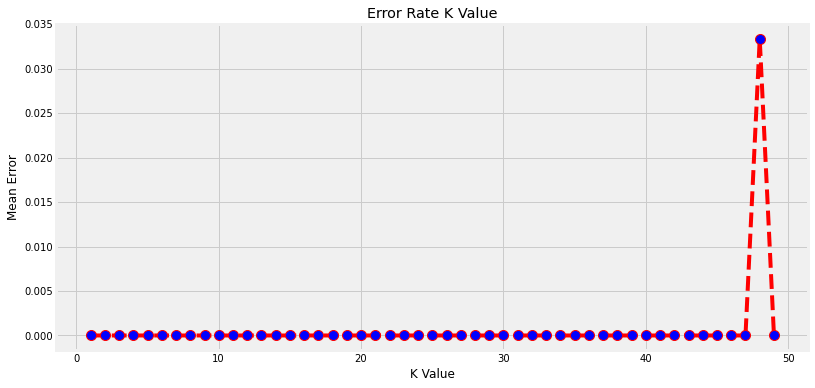

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(range(1,50), error_rate, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Error Rate K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')

From the output we can see that the mean error is zero when the value of the K is between **1 and 48**.

<a id="13"></a>
<h2 style='background:black; border:10; color:white'><center>13) MODEL PERFORMANCE USING CROSS-VALIDATION </center><h2>

In [21]:
param_grid = {'n_neighbors':np.arange(1,50)}

In [22]:
knn = KNeighborsClassifier()
knn_cv= GridSearchCV(knn,param_grid,cv=5)
knn_cv.fit(X,y)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])})

In [23]:
round(knn_cv.best_score_,2)*100

88.0

In [24]:
knn_cv.best_params_

{'n_neighbors': 2}

## The algorithm works best with 2 neighbors giving accuracy of 88%

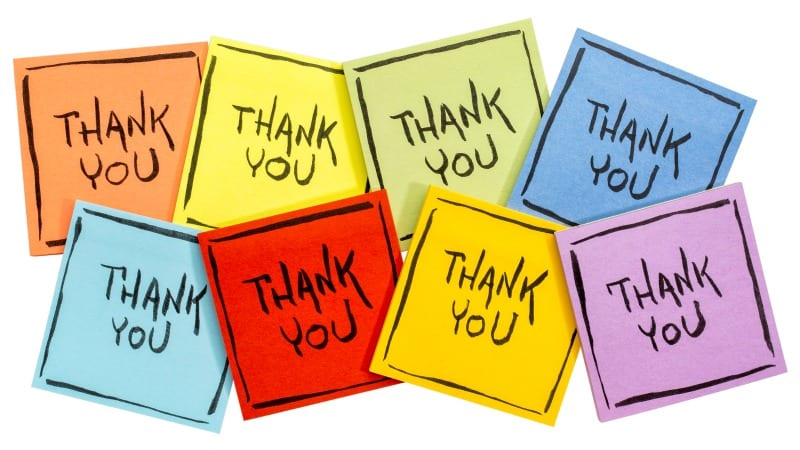